In [ ]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt r

In [2]:
df = pd.read_csv(r"C:\Users\Admin\Documents\Machine Learning\uncleaned_churn_data.csv")

In [3]:
df.head(3)

,Customer_ID,Customer_Age,Tenure_Months,Monthly_Charges,Total_Data_GB,Support_Calls,Contract_Type,Payment_Method,Churn_Risk_Score
0,CUST-00001,56,41.0,50.526243,218.186805,7.0,One year,Bank transfer,63.855674
1,CUST-00002,69,NaN,87.892877,796.514622,7.0,Two year,Credit card,80.051363
2,CUST-00003,46,45.0,108.938809,317.713909,3.0,m-2-m,Mailed check,41.782559


In [4]:
df.drop(columns="Customer_ID", inplace=True)

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

Customer_Age          0
Tenure_Months       900
Monthly_Charges     900
Total_Data_GB       900
Support_Calls       900
Contract_Type       900
Payment_Method        0
Churn_Risk_Score      0
dtype: int64

In [7]:
df.dropna(inplace=True)

In [8]:
df.info()

<class 'pandas.DataFrame'>
Index: 13929 entries, 0 to 17998
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer_Age      13929 non-null  int64  
 1   Tenure_Months     13929 non-null  float64
 2   Monthly_Charges   13929 non-null  float64
 3   Total_Data_GB     13929 non-null  float64
 4   Support_Calls     13929 non-null  float64
 5   Contract_Type     13929 non-null  str    
 6   Payment_Method    13929 non-null  str    
 7   Churn_Risk_Score  13929 non-null  float64
dtypes: float64(5), int64(1), str(2)
memory usage: 1.3 MB


In [9]:
df["Contract_Type"].unique()

<ArrowStringArray>
['One year', 'm-2-m', 'Two year', 'Month-to-month', '1-yr']
Length: 5, dtype: str

In [10]:
df["Payment_Method"].unique()

<ArrowStringArray>
['Bank transfer', 'Mailed check', 'Electronic check', 'Credit card',
 'E-Check']
Length: 5, dtype: str

In [11]:
df["Contract_Type"] = df["Contract_Type"].replace({'m-2-m': 'Month-to-month', '1-yr':'One year' })

In [12]:
df["Payment_Method"] = df["Payment_Method"].replace({'E-Check': 'Electronic check'})

In [13]:
df['Contract_Type'].unique()

<ArrowStringArray>
['One year', 'Month-to-month', 'Two year']
Length: 3, dtype: str

<Axes: ylabel='Customer_Age'>

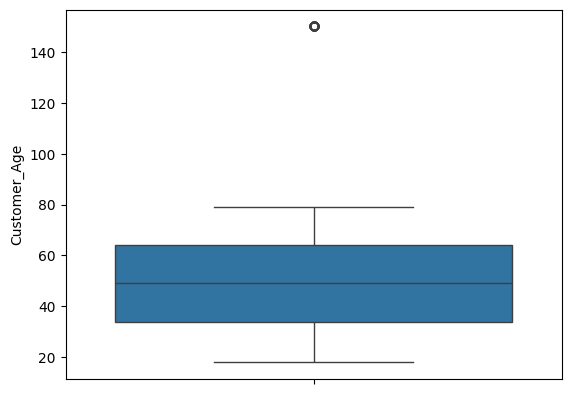

In [14]:
sns.boxplot(data=df, y="Customer_Age")

In [15]:
df["Customer_Age"].describe()

count    13929.000000
mean        49.178836
std         19.313687
min         18.000000
25%         34.000000
50%         49.000000
75%         64.000000
max        150.000000
Name: Customer_Age, dtype: float64

In [16]:
q1 = 34.0
q3 = 64.0

In [17]:
IQR = q3 - q1 
IQR 

30.0

In [18]:
ub = q3 + 1.5*IQR 
ub 

109.0

In [19]:
lb = q1 - 1.5*IQR 
lb 

-11.0

In [20]:
df= df[(df["Customer_Age"]>lb)&(df["Customer_Age"]<ub)]

<Axes: ylabel='Customer_Age'>

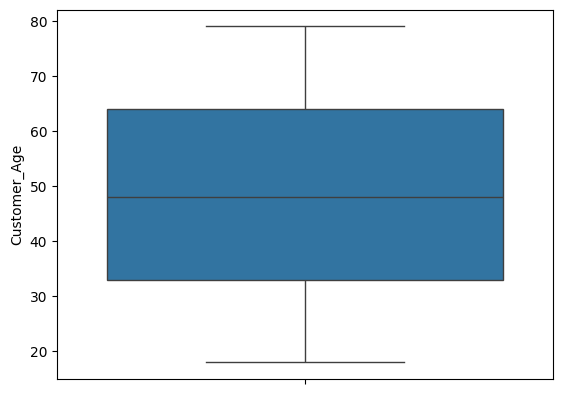

In [21]:
sns.boxplot(data=df, y="Customer_Age")

In [22]:
df.columns

Index(['Customer_Age', 'Tenure_Months', 'Monthly_Charges', 'Total_Data_GB',
       'Support_Calls', 'Contract_Type', 'Payment_Method', 'Churn_Risk_Score'],
      dtype='str')

In [23]:
df["Monthly_Charges"].describe()

count    13849.000000
mean        91.704124
std        324.626584
min         20.000554
25%         45.020072
50%         69.983115
75%         94.998290
max       7181.771077
Name: Monthly_Charges, dtype: float64

In [24]:
q1 = 45.0
q3 = 94.9

In [25]:
IQR = q3 - q1 

In [26]:
uf = q3 + 1.5*IQR 
uf 

169.75

In [27]:
lf = q1 - 1.5*IQR 
lf 

-29.85000000000001

In [28]:
df = df[(df["Monthly_Charges"]>lf)&(df["Monthly_Charges"]<uf)]

<Axes: ylabel='Monthly_Charges'>

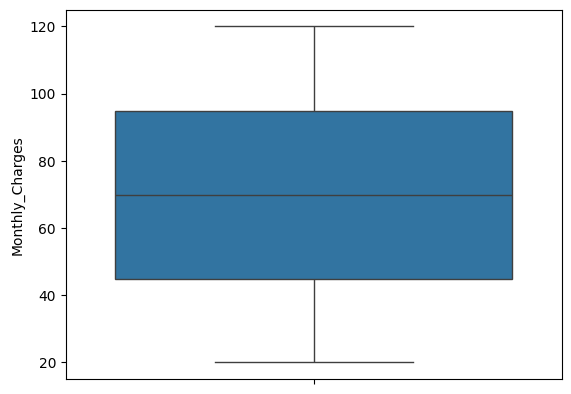

In [29]:
sns.boxplot(data=df, y="Monthly_Charges")

In [30]:
df["Support_Calls"].describe()

count    13776.000000
mean         5.236571
std          9.762821
min          0.000000
25%          2.000000
50%          5.000000
75%          7.000000
max        125.000000
Name: Support_Calls, dtype: float64

In [31]:
Q1 = 2.0
Q3 = 7.0

In [32]:
IQR = Q3 - Q1 

In [33]:
UB = Q3 + 1.5*IQR 
UB 

14.5

In [34]:
LB = Q1 - 1.5*IQR
LB 

-5.5

In [35]:
df = df[(df["Support_Calls"]>LB)&(df["Support_Calls"]<UB)]

<Axes: ylabel='Support_Calls'>

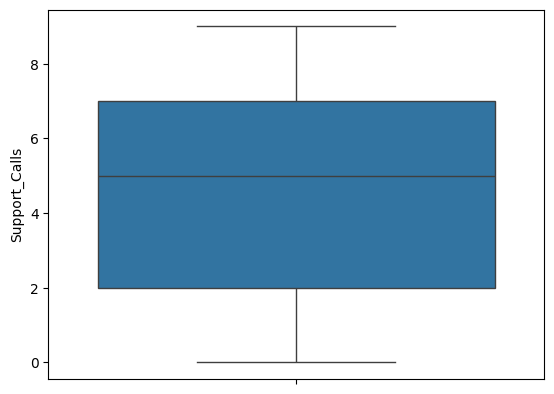

In [36]:
sns.boxplot(data=df, y="Support_Calls")

In [37]:
df = df[(df["Churn_Risk_Score"]>0)&(df["Churn_Risk_Score"]<100)]

<Axes: ylabel='Churn_Risk_Score'>

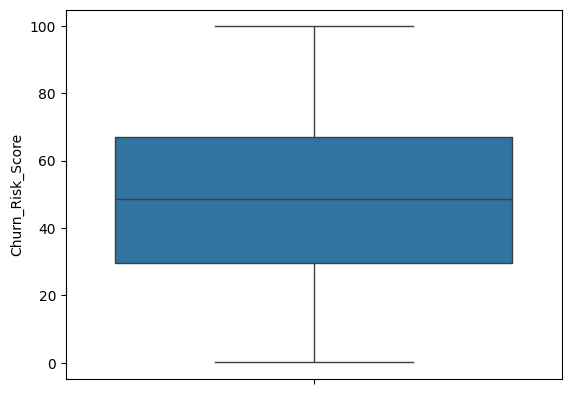

In [38]:
sns.boxplot(data=df, y="Churn_Risk_Score")

In [39]:
from sklearn.preprocessing import LabelEncoder
enc = LabelEncoder()

In [40]:
df["Contract_Type"] = enc.fit_transform(df["Contract_Type"])

In [41]:
df["Contract_Type"].head()

0    1
2    0
3    0
5    2
7    1
Name: Contract_Type, dtype: int64

In [42]:
df["Payment_Method"] = enc.fit_transform(df["Payment_Method"])

In [43]:
df.head(4)

,Customer_Age,Tenure_Months,Monthly_Charges,Total_Data_GB,Support_Calls,Contract_Type,Payment_Method,Churn_Risk_Score
0,56,41.0,50.526243,218.186805,7.0,1,0,63.855674
2,46,45.0,108.938809,317.713909,3.0,0,3,41.782559
3,32,32.0,87.456765,483.113606,1.0,0,3,27.398196
5,25,56.0,74.356059,808.117672,4.0,2,3,39.797217


In [44]:
df.describe()

,Customer_Age,Tenure_Months,Monthly_Charges,Total_Data_GB,Support_Calls,Contract_Type,Payment_Method,Churn_Risk_Score
count,13478.000000,13478.000000,13478.000000,13478.000000,13478.000000,13478.000000,13478.000000,13478.000000
mean,48.609660,35.143196,69.868683,747.002920,4.526562,0.921947,1.518178,48.434688
std,17.799143,20.738645,28.651437,4925.602896,2.877891,0.811722,1.097227,23.373929
min,18.000000,0.000000,20.000554,10.008348,0.000000,0.000000,0.000000,0.070370
25%,33.000000,17.000000,45.311396,259.051483,2.000000,0.000000,1.000000,29.450912
50%,48.000000,35.000000,69.841647,503.992014,5.000000,1.000000,2.000000,48.624603
75%,64.000000,53.000000,94.657381,752.690141,7.000000,2.000000,2.000000,67.047512
max,79.000000,71.000000,119.989056,99999.000000,9.000000,2.000000,3.000000,99.835085


In [45]:
#Scaling
from sklearn.preprocessing import StandardScaler 

In [46]:
scale = StandardScaler()

In [47]:
df["Total_Data_GB"] = scale.fit_transform(df[["Total_Data_GB"]])

In [48]:
df["Total_Data_GB"].head()

0   -0.107365
2   -0.087158
3   -0.053577
5    0.012408
7   -0.117386
Name: Total_Data_GB, dtype: float64

In [49]:
df["Total_Data_GB"].describe()

count    1.347800e+04
mean    -5.271871e-18
std      1.000037e+00
min     -1.496308e-01
25%     -9.906798e-02
50%     -4.933811e-02
75%      1.154667e-03
max      2.015097e+01
Name: Total_Data_GB, dtype: float64